# SVD Spatial Modes of a Functional Ultrasound (fUSI) Run

This notebook loads a 4D fUSI run (NIfTI format), preprocesses it
(high-pass filter, spatial smoothing, temporal normalization), and
computes SVD spatial modes.

In [52]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt
from scipy.ndimage import uniform_filter

## Load data

In [53]:
base_path = Path("/Users/clairenastaskin/data/sub-Forest002/ses-20260215/task_audio_ARIA")
nii_path = base_path / "fusi_run_clean.nii.gz"
mask_path = base_path / "bbc3_mask.nii.gz"

img = nib.load(nii_path)
data = img.get_fdata()  # (nx, ny, nz, nt)

mask_img = nib.load(mask_path)
mask = mask_img.get_fdata().astype(bool)  # (nx, ny, nz)

# Zero out NaNs (voxels outside the brain) so they don't poison filtering
data = np.nan_to_num(data, nan=0.0)

nx, ny, nz, nt = data.shape
print(f"Data shape: {data.shape}  (nx={nx}, ny={ny}, nz={nz}, nt={nt})")
print(f"Mask voxels: {mask.sum()} / {mask.size}")

Data shape: (117, 56, 50, 279)  (nx=117, ny=56, nz=50, nt=279)
Mask voxels: 199643 / 327600


In [54]:
# Acquisition parameters
TR = 1.6        # seconds (ensemble repetition interval)
fs = 1.0 / TR   # sampling frequency in Hz
print(f"TR = {TR} s, fs = {fs:.4f} Hz")

TR = 1.6 s, fs = 0.6250 Hz


## Spatial smoothing

Uniform (box) filter of size 5x5 within each slice, applied to every
volume independently — matching the MATLAB 2D `filter2` approach.

In [55]:
N_filt = 5  # kernel size in pixels (in-plane)

# uniform_filter with size=(5,5,1,1) smooths only in x,y (not z or t)
data_smooth = uniform_filter(data, size=(N_filt, N_filt, 1, 1))
print("Spatial smoothing done.")

Spatial smoothing done.


## Temporal normalization

For each voxel: subtract the temporal mean, then divide by the L2 norm
across time. This makes each voxel's time-course unit-length.

In [56]:
# Subtract temporal mean
data_norm = data_smooth - data_smooth.mean(axis=3, keepdims=True)

# Divide by L2 norm across time
l2_norm = np.sqrt(np.sum(data_norm ** 2, axis=3, keepdims=True))
# Avoid division by zero (e.g. outside brain)
l2_norm[l2_norm == 0] = 1.0
data_norm = data_norm / l2_norm

# Zero out any remaining NaN/Inf (safety)
data_norm[~np.isfinite(data_norm)] = 0.0

# Apply brain mask
data_norm *= mask[..., np.newaxis]

print("Temporal normalization done.")

Temporal normalization done.


## SVD

Reshape spatial dims to (n_voxels, nt) and compute the thin SVD directly.
`U` columns are the spatial modes, `S` the singular values, `Vt` rows
are the temporal signatures.

In [57]:
n_voxels = nx * ny * nz

# Reshape to (voxels, time)
X = data_norm.reshape(n_voxels, nt)

# Thin SVD: X = U @ diag(S) @ Vt
U, S, Vt = np.linalg.svd(X, full_matrices=False)

# U:  (n_voxels, nt) — spatial modes (columns)
# S:  (nt,)          — singular values
# Vt: (nt, nt)       — temporal signatures (rows)

# Scale spatial modes by singular values for visualization: US = U * S
US = U * S[np.newaxis, :]

# Reshape spatial modes back to volume
US_vol = US.reshape(nx, ny, nz, nt)

print(f"SVD done.  X shape: {X.shape}")
print(f"Top 5 singular values: {S[:5]}")
print(f"Spatial modes volume shape: {US_vol.shape}")

SVD done.  X shape: (327600, 279)
Top 5 singular values: [443.2244912   42.68674539  12.17234515   7.20894528   6.19450092]
Spatial modes volume shape: (117, 56, 50, 279)


## Visualize SVD spatial modes

Show the first 12 modes at a selected slice. Each mode's colormap is
centered at zero with symmetric limits, matching the MATLAB display.

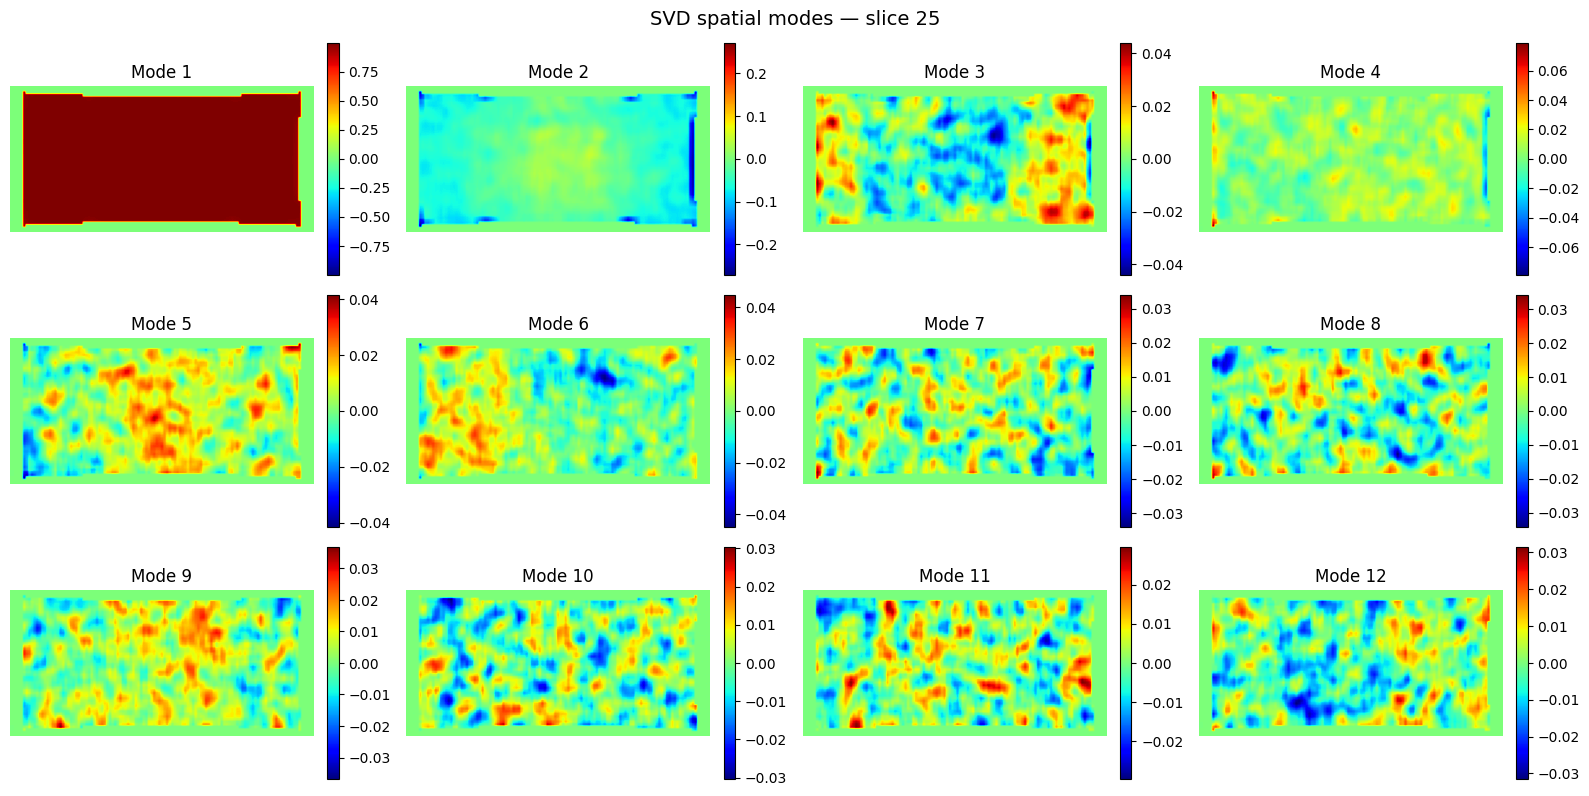

Top 12 SVD modes saved as NIfTI files.


In [58]:
slice_idx = nz // 2  # middle slice — change as needed
n_modes = 12

fig, axes = plt.subplots(3, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    mode_slice = US_vol[:, :, slice_idx, i]
    vmax = np.max(np.abs(mode_slice))
    im = ax.imshow(mode_slice.T, origin="lower", cmap="jet",
                   vmin=-vmax, vmax=vmax)
    ax.set_title(f"Mode {i + 1}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"SVD spatial modes — slice {slice_idx}", fontsize=14)
plt.tight_layout()
plt.show()

# Save top 12 modes as NIfTI volumes
for i in range(n_modes):
    mode_vol = US_vol[:, :, :, i]
    mode_img = nib.Nifti1Image(mode_vol, img.affine, img.header)
    mode_img.to_filename(base_path / f"svd_mode_{i + 1:02d}.nii.gz")
print(f"Top {n_modes} SVD modes saved as NIfTI files.")

## Temporal signatures of each mode

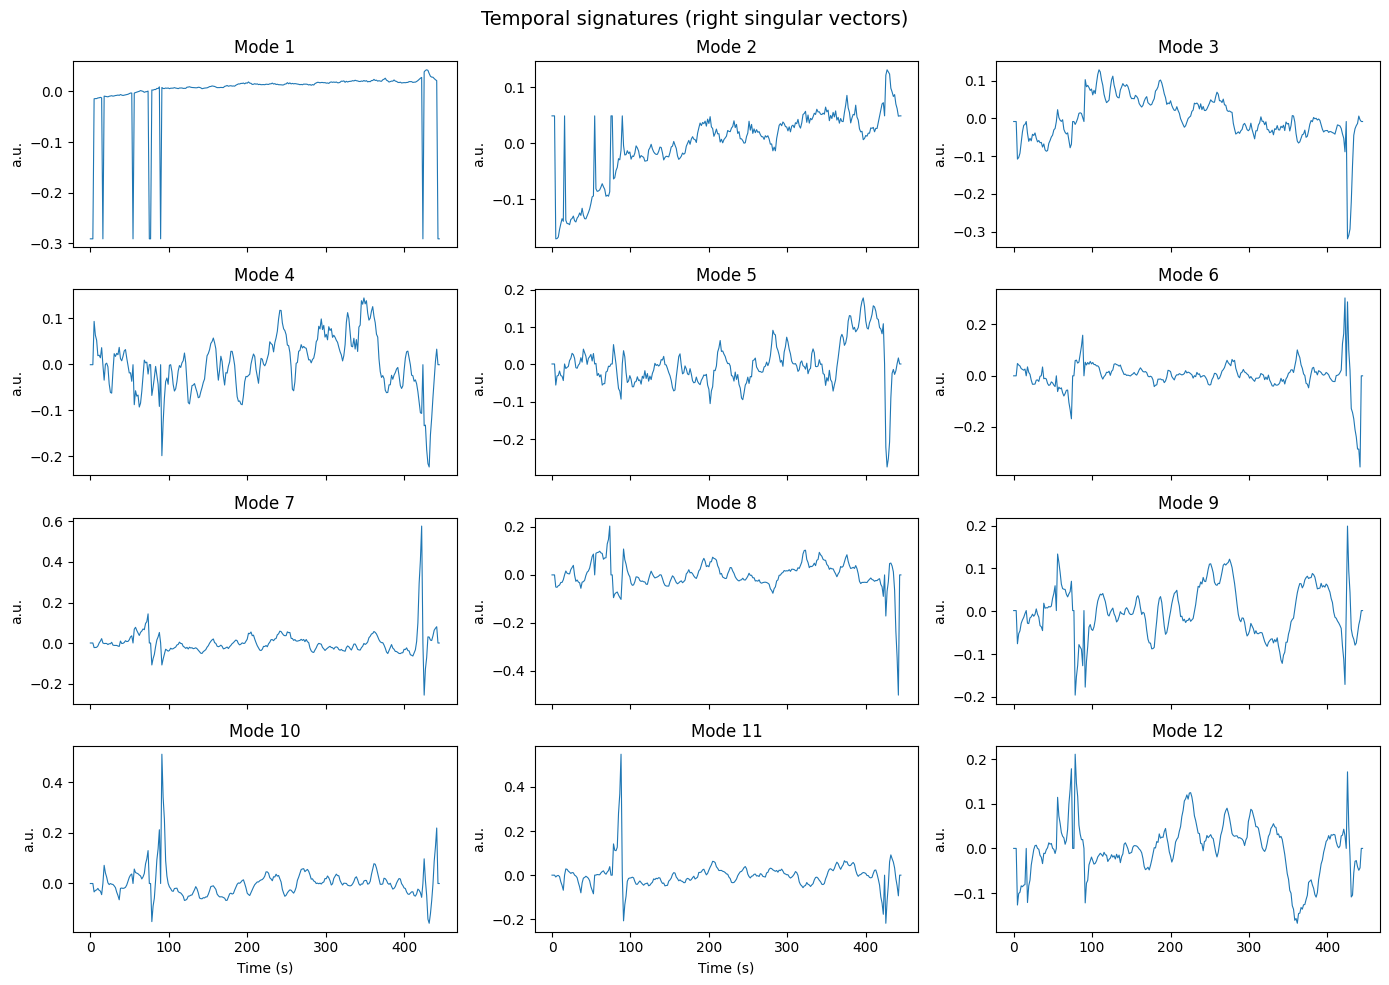

In [59]:
time = np.arange(nt) * TR

fig, axes = plt.subplots(4, 3, figsize=(14, 10), sharex=True)

for i, ax in enumerate(axes.flat):
    ax.plot(time, Vt[i, :], linewidth=0.8)
    ax.set_title(f"Mode {i + 1}")
    ax.set_ylabel("a.u.")

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("Temporal signatures (right singular vectors)", fontsize=14)
plt.tight_layout()
plt.show()